In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 10. 実践的な ML パイプライン — 生データから運用まで

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- 生データ → 前処理 → モデルを **1 つの `Pipeline`** にまとめる(リーク防止・再現性)
- **GridSearchCV / RandomizedSearchCV** でのハイパラ探索、**ネスト交差検証**
- **再現性** と簡単な **実験記録**
- モデルの **保存・再読込・新データ推論**
- **ドリフト** による劣化の監視と **誤差分析**、本番チェックリスト

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from sklearn import set_config
set_config(display="diagram")   # render pipelines as diagrams

from ml_textbook import datasets, preprocessing, pipelines, plotting, widgets
from ml_textbook.models import get_logistic_regression
from sklearn.model_selection import train_test_split, cross_val_score

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. エンドツーエンドのパイプライン

生の Titanic データ(数値 + カテゴリ + 欠損)を、`ColumnTransformer`(前処理)+ モデルの
**1 つの `Pipeline`** にまとめます。これで前処理は常に訓練側だけで fit され、保存も推論も一括です。

In [3]:
X, y = datasets.make_titanic_like_dataset(n=900, seed=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
numeric, categorical = preprocessing.split_feature_types(X)
pipe = pipelines.make_full_pipeline(numeric, categorical, get_logistic_regression())
pipe   # rendered as a diagram

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}_

## 2. ハイパーパラメータ探索 — GridSearchCV

前処理とモデルのパラメータを **同時に** 交差検証で探索します。`Pipeline` なので、
スケーラの種類やモデルの正則化を一括でチューニングできます。

In [4]:
param_grid = {
    "preprocess__num__scale": [preprocessing.StandardScaler(), preprocessing.RobustScaler()],
    "model__C": [0.1, 1.0, 10.0],
}
search = pipelines.grid_search(pipe, param_grid, X_train, y_train, cv=5)
print("best params:", search.best_params_)
print(f"best CV accuracy: {search.best_score_:.3f}")

best params: {'model__C': 0.1, 'preprocess__num__scale': RobustScaler()}
best CV accuracy: 0.788


### ハイパラ探索のヒートマップ

Random Forest を例に、`n_estimators` × `max_depth` の交差検証スコアをヒートマップで一望します
(Plotly なのでホバーで値が見え、静的 HTML でも動きます)。

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

bc = datasets.load_breast_cancer_dataset()
depths = [2, 3, 5, 8, None]
trees = [25, 50, 100, 200, 400]
grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    {"max_depth": depths, "n_estimators": trees}, cv=5,
).fit(bc.data, bc.target)
scores = grid.cv_results_["mean_test_score"].reshape(len(depths), len(trees))

fig = go.Figure(go.Heatmap(
    z=scores, x=[str(t) for t in trees], y=[str(d) for d in depths],
    colorscale="Viridis", colorbar={"title": "CV acc"},
    text=np.round(scores, 3), texttemplate="%{text}"))
fig.update_layout(title="GridSearchCV: RF accuracy over (max_depth, n_estimators)",
                  xaxis_title="n_estimators", yaxis_title="max_depth",
                  width=680, height=440, margin={"l": 60, "r": 20, "t": 60, "b": 50})
fig.show()
print("best:", grid.best_params_, "score:", round(grid.best_score_, 3))

best: {'max_depth': 8, 'n_estimators': 100} score: 0.965


## 3. RandomizedSearchCV とネスト交差検証

探索空間が広いときは **RandomizedSearchCV** が効率的。また、**チューニングしたうえでの汎化** を正直に測るには
**ネスト交差検証**(内側で選び、外側で評価)を使います。普通の CV は「選んだ fold で採点」するので楽観的です。

In [6]:
from scipy.stats import loguniform

rnd = pipelines.random_search(
    pipe, {"model__C": loguniform(1e-2, 1e2)}, X_train, y_train, n_iter=15, cv=5, seed=0)
print(f"random search best C = {rnd.best_params_['model__C']:.3f}, CV acc = {rnd.best_score_:.3f}")

nested = pipelines.nested_cv_score(pipe, {"model__C": [0.1, 1.0, 10.0]}, X_train, y_train, inner=3, outer=5)
print(f"nested CV accuracy   = {nested.mean():.3f} +/- {nested.std():.3f}  (honest tuning estimate)")

random search best C = 1.568, CV acc = 0.790


nested CV accuracy   = 0.788 +/- 0.035  (honest tuning estimate)


## 4. 再現性と実験記録

再現性の最低条件: **seed 固定・バージョン記録・パイプライン化**。実験は小さな辞書に
**パラメータ + スコア** を残すだけでも後で比較できます(本格的には MLflow / Weights & Biases)。

In [7]:
import sklearn, platform
runs = []
for C in [0.1, 1.0, 10.0]:
    p = pipelines.make_full_pipeline(numeric, categorical, get_logistic_regression(C=C))
    cv = cross_val_score(p, X_train, y_train, cv=5).mean()
    runs.append({"model": "logreg", "C": C, "cv_acc": round(float(cv), 4)})
runs_df = pd.DataFrame(runs)
print(runs_df.to_string(index=False))
print(f"\nenv: python {platform.python_version()}, scikit-learn {sklearn.__version__}, seed {RANDOM_SEED}")

 model    C  cv_acc
logreg  0.1  0.7867
logreg  1.0  0.7881
logreg 10.0  0.7867

env: python 3.12.3, scikit-learn 1.9.0, seed 0


## 5. モデルの保存・再読込・新データ推論

学習済みパイプラインは **前処理ごと** 1 ファイルに保存できます。再読込して、生の新規データ
(欠損やカテゴリを含む素のまま)にそのまま推論できるのが `Pipeline` の強みです。

In [8]:
import tempfile, os

best = search.best_estimator_.fit(X_train, y_train)
path = os.path.join(tempfile.gettempdir(), "titanic_pipeline.joblib")
pipelines.save_pipeline(best, path)
reloaded = pipelines.load_pipeline(path)

# Brand-new raw passengers (note: missing age, raw categories) — no manual preprocessing needed.
new_passengers = pd.DataFrame({
    "pclass": [1, 3], "sex": ["female", "male"], "age": [np.nan, 25.0],
    "sibsp": [0, 1], "parch": [0, 0], "fare": [120.0, 7.5], "embarked": ["C", "S"],
})
pred = pipelines.predict_new(reloaded, new_passengers)
proba = reloaded.predict_proba(new_passengers)[:, 1]
print("saved to:", path)
print("predicted survival:", pred, " P(survive):", proba.round(3))

saved to: /tmp/titanic_pipeline.joblib
predicted survival: [1 0]  P(survive): [0.898 0.175]


## 6. ドリフト監視 — 入力分布が変わると劣化する

本番では入力分布が時間とともに変わります(**covariate drift**)。学習時の分布から離れるほど精度は落ちます。
テスト特徴を少しずつシフトさせ、精度の低下を監視します。

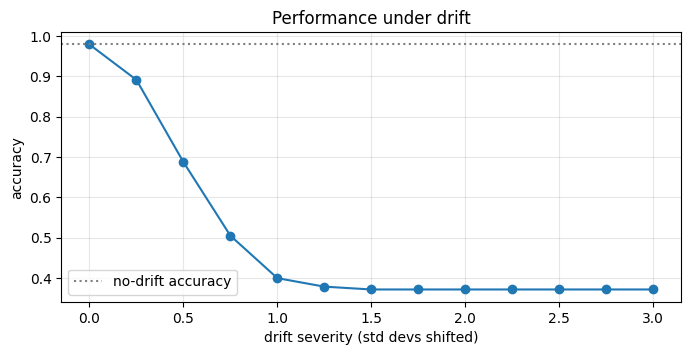

accuracy: no drift 0.979 -> 3σ drift 0.372


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data.to_numpy(), bc.target.to_numpy(),
                                              test_size=0.5, random_state=0, stratify=bc.target)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xb_tr, yb_tr)
std = Xb_tr.std(axis=0)
severities = np.linspace(0, 3, 13)
accs = [model.score(Xb_te + s * std, yb_te) for s in severities]

ax = plotting.plot_drift_simulation(severities, accs, drift_at=None, metric_name="accuracy")
ax.set_xlabel("drift severity (std devs shifted)")
ax.axhline(accs[0], color="gray", ls=":", label="no-drift accuracy"); ax.legend()
plt.show()
print(f"accuracy: no drift {accs[0]:.3f} -> 3σ drift {accs[-1]:.3f}")

### インタラクティブ(JupyterLab のみ): ドリフトの強さ

ドリフト量のスライダーで、精度がどこから崩れ始めるかを確かめます。

In [10]:
Xm, ym = datasets.make_classification_dataset(n=600, n_features=2, class_sep=1.3, seed=0)
widgets.drift_severity_explorer(Xm, ym)

interactive(children=(FloatSlider(value=0.0, description='drift σ', max=3.0, step=0.25), Output()), _dom_class…

<function ml_textbook.widgets.drift_severity_explorer.<locals>.draw(severity)>

## 7. 誤差分析 — どこで間違えるか

全体精度だけ見ても改善点は分かりません。**部分集団ごと** の誤り率を見ると、弱点が見えます。
Titanic で、性別 × 客室クラス別の誤分類率を確認します。

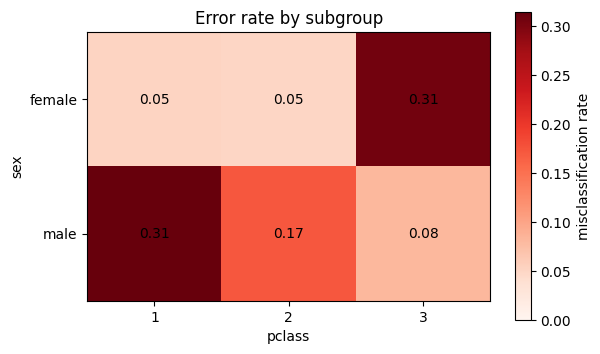

In [11]:
best_titanic = search.best_estimator_.fit(X_train, y_train)
pred_test = best_titanic.predict(X_test)
err = X_test.copy()
err["wrong"] = (pred_test != y_test.to_numpy()).astype(int)
by_group = err.groupby(["sex", "pclass"])["wrong"].mean().unstack()

fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.imshow(by_group.to_numpy(), cmap="Reds", vmin=0)
ax.set_xticks(range(by_group.shape[1])); ax.set_xticklabels(by_group.columns)
ax.set_yticks(range(by_group.shape[0])); ax.set_yticklabels(by_group.index)
for i in range(by_group.shape[0]):
    for j in range(by_group.shape[1]):
        ax.text(j, i, f"{by_group.to_numpy()[i, j]:.2f}", ha="center", va="center")
ax.set_xlabel("pclass"); ax.set_ylabel("sex"); ax.set_title("Error rate by subgroup")
plt.colorbar(im, ax=ax, label="misclassification rate"); plt.show()

## 8. 本番 ML チェックリスト

- [ ] 前処理は **すべて `Pipeline` の中**(リーク防止)
- [ ] 評価は **交差検証 + 取り置きテスト**、テストは最後に一度だけ
- [ ] 指標は問題に合わせて選んだか(不均衡・コスト・較正)
- [ ] ハイパラ探索は **ネスト CV** で正直に評価したか
- [ ] **seed・ライブラリ版** を記録、パイプラインを保存
- [ ] 新データに **生のまま** 推論できるか(前処理同梱)
- [ ] **ドリフト監視** と **再学習** の運用、誤差分析で弱点を把握
- [ ] 解釈(09 章)で妥当性と公平性を確認

## 9. まとめ

- `Pipeline` + `ColumnTransformer` が前処理・モデル・探索・保存・推論を一本化し、リークを構造的に防ぐ。
- ハイパラは Grid/Randomized で探索、汎化は **ネスト CV** で正直に測る。
- 再現性(seed・版・保存)と簡単な実験記録を最初から。
- デプロイ後は **ドリフト監視・再学習・誤差分析** が本番品質を支える。
- 「正しく定式化し、正しく前処理し、正しく評価し、正しく解釈する」— 本書全体の総まとめ。

## 10. Exercises

1. `param_grid` にモデル種別(logreg/RF)も加え、最良の組み合わせを探せ(`Pipeline` の `set_params`)。
2. ネスト CV と通常 CV のスコア差を測り、楽観バイアスの大きさを確認せよ。
3. 保存したパイプラインを別プロセス(別セル)で読み込み、同じ予測が出るか確かめよ。
4. ドリフトを「一部の特徴だけ」シフトさせると精度低下はどう変わるか。
5. (発展)誤差分析で最も誤る部分集団に対し、特徴追加や重み付けで改善できるか試せ。

## 11. Common Mistakes

- **前処理をパイプライン外で実施。** リークと、推論時の再現ミスの温床。
- **チューニング結果をそのまま汎化性能と報告。** ネスト CV を使う。
- **保存をモデルだけにする。** 前処理を含めないと推論時に壊れる。`Pipeline` ごと保存。
- **デプロイして放置。** ドリフトで静かに劣化する。監視と再学習を仕組み化。